In [1]:
%load_ext autoreload
%autoreload 2

import logging
logging.basicConfig(level=logging.WARNING)

from glob import glob
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import pickle as pkl

from noisepy.seis.io.h5store import DASH5DataStore
from datetime import datetime, timezone
from datetimerange import DateTimeRange
from noisepy.seis.io.datatypes import CCMethod, ConfigParameters, FreqNorm, RmResp, StackMethod, TimeNorm, Channel
from noisepy.seis.io.numpystore import NumpyCCStore
from noisepy.seis.io.asdfstore import ASDFStackStore

from noisepy.seis import cross_correlate, stack_cross_correlations, __version__  

/home/jmanos/miniconda3/envs/noisepy/lib/python3.10/site-packages/noisepy/seis/io/utils.py:13: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:

event_num = 68
with open(f'manual_picks_located/event_{event_num}_location.pkl', 'rb') as f:
    locations = pkl.load(f)
mean_params_good = np.mean(locations,axis=0)
std_params_good = np.std(locations,axis=0)


event_datetime = datetime.fromtimestamp(mean_params_good[3], tz=timezone.utc)
wanted_file_str = 'Eastwind_decimator_2024-12-'+str(event_datetime.day)+'_'+event_datetime.strftime("%H")+"."+event_datetime.strftime("%M")+"*"

In [3]:
# ### timeframe for analysis (for a range of files) ###
# file_start_str = sorted(glob('/1-fnp/petasaur/p-jbod1/antarctica2425/incoming/Eastwind_decimator_2024*'))[150][-26:-7]
# file_start_dt = datetime.strptime(file_start_str, '%Y-%m-%d_%H.%M.%S')
# file_start_dt_aware = file_start_dt.replace(tzinfo=timezone.utc)

# file_end_str = sorted(glob('/1-fnp/petasaur/p-jbod1/antarctica2425/incoming/Eastwind_decimator_2024*'))[210][-26:-7]
# file_end_dt = datetime.strptime(file_end_str, '%Y-%m-%d_%H.%M.%S')
# file_end_dt_aware = file_end_dt.replace(tzinfo=timezone.utc)

# ### If we want to focus on one file ###
file_start_dt_aware = datetime(year = event_datetime.year,
                                month = event_datetime.month,
                                day = event_datetime.day,
                                hour = event_datetime.hour,
                                minute = event_datetime.minute-30,
                                tzinfo=timezone.utc)


file_end_dt_aware = datetime(year = event_datetime.year,
                                month = event_datetime.month,
                                day = event_datetime.day,
                                hour = event_datetime.hour,
                                minute = event_datetime.minute+2, 
                                tzinfo=timezone.utc)

start = file_start_dt_aware
end = file_end_dt_aware


time_range = DateTimeRange(start, end)
print(time_range)

# space of interesst (channels)
cha_start = 80
cha_end = 120+1# one more than interessted
cha_step = 1
channel_list = list(np.arange(cha_start,cha_end, cha_step))

2024-12-19T03:25:00+0000 - 2024-12-19T03:57:00+0000


In [4]:
file = glob('/1-fnp/petasaur/p-jbod1/antarctica2425/incoming/'+wanted_file_str)[0]
# file = DAS_DATA + wanted_file_str
DAS_DATA = "/1-fnp/petasaur/p-jbod1/antarctica2425/incoming/"

with h5py.File(file,'r') as f:
    gauge_len = f['Acquisition'].attrs['GaugeLength']
    delta_space = f['Acquisition'].attrs['SpatialSamplingInterval']
    sample_rate  = f['Acquisition']['Raw[0]'].attrs['OutputDataRate']
    num_channel = f['Acquisition']['Raw[0]'].attrs['NumberOfLoci']
    num_sample  = len(f['Acquisition']['Raw[0]']['RawDataTime'][:])
    minute_data = f['Acquisition']['Raw[0]']['RawData'][:,:]

delta_time = 1.0 / sample_rate

date = file.split('_')[2]
time = file.split('_')[3]

print(f'UTC: {date} {time}')
print('-'*24)
print(f'1-min data with shape: {minute_data.shape}')
print('-'*24)
print(f'Gauge length (m): {gauge_len}')
print(f'Channel spacing (m): {delta_space}')
print(f'Number of channels: {num_channel}')
print(f'Total cable length (m): {delta_space * num_channel}')
print('-'*24)
print(f'Sampling rate (Hz): {sample_rate}')
print(f'Number of samples in file: {num_sample}')
print(f'Total duration (s): {delta_time * num_sample:.2f}')

UTC: 2024-12-19 03.55.00
------------------------
1-min data with shape: (120000, 351)
------------------------
Gauge length (m): 6.380952536802641
Channel spacing (m): 6.380952536802641
Number of channels: 351
Total cable length (m): 2239.7143404177273
------------------------
Sampling rate (Hz): 2000.0
Number of samples in file: 120000
Total duration (s): 60.00


In [5]:

raw_store = DASH5DataStore(path = DAS_DATA,
                           sampling_rate=sample_rate,
                           channel_numbers=channel_list,
                           file_naming = "Eastwind_decimator_%Y-%m-%d_%H.%M.%S_UTC.h5",
                           array_name = "Eastwind",
                           date_range = time_range) # Store for reading raw data from S3 bucket
raw_store.fs

In [6]:
span = raw_store.get_timespans()
channels = raw_store.get_channels(span[0])
d = raw_store.read_data(span[20], channels[20])
d.stream

1 Trace(s) in Stream:
Eastwind.00100..XXZ | 2024-12-19T03:45:00.000000Z - 2024-12-19T03:45:59.999500Z | 2000.0 Hz, 120000 samples

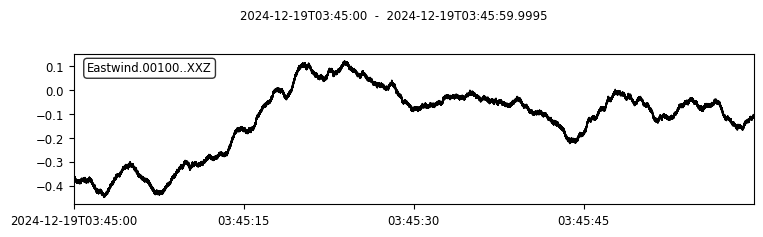

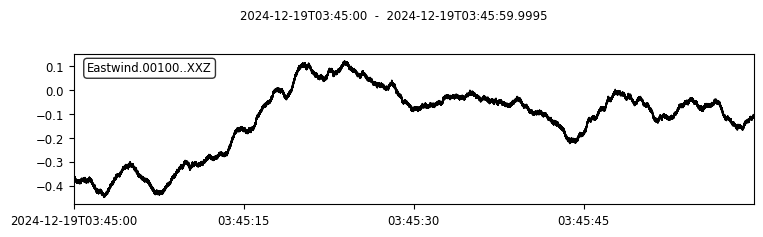

In [7]:
d.stream.plot()

In [8]:

import shutil


path = "./output_ew_single_event" 

if os.path.exists(path):
    shutil.rmtree(path)
os.makedirs(path, exist_ok=True)
# os.makedirs(path, exist_ok=True)
cc_data_path = os.path.join(path, "CCF")
stack_data_path = os.path.join(path, "STACK")

In [440]:
config = ConfigParameters()
config.start_date = start
config.end_date = end
config.acorr_only = False # only perform auto-correlation or not
config.xcorr_only = True # only perform cross-correlation or not

config.inc_hours = 0
config.sampling_rate = 2000  # (int) Sampling rate in Hz of desired processing (it can be different than the data sampling rate)
config.cc_len = 1  # (int) basic unit of data length for fft (sec)
config.step = 1.  # (float) overlapping between each cc_len (sec)

config.ncomp = 1  # 1 or 3 component data (needed to decide whether do rotation)
config.stationxml = False  # station.XML file used to remove instrument response for SAC/miniseed data
config.rm_resp = RmResp.NO  # select 'no' to not remove response and use 'inv' if you use the stationXML,'spectrum',

############## NOISE PRE-PROCESSING ##################
config.freqmin, config.freqmax = 10., 40.0  # broad band filtering of the data before cross correlation
config.max_over_std  = 10*9  # threshold to remove window of bad signals: set it to 10*9 if prefer not to remove them

################### SPECTRAL NORMALIZATION ############
config.freq_norm = FreqNorm.RMA  # choose between "rma" for a soft whitening or "no" for no whitening. Pure whitening is not implemented correctly at this point.
config.smoothspect_N = 1  # moving window length to smooth spectrum amplitude (points)

#################### TEMPORAL NORMALIZATION ##########
config.time_norm = TimeNorm.ONE_BIT # 'no' for no normalization, or 'rma', 'one_bit' for normalization in time domain,
config.smooth_N = 100  # moving window length for time domain normalization if selected (points)

############ cross correlation ##############
config.cc_method = CCMethod.XCORR # 'xcorr' for pure cross correlation OR 'deconv' for deconvolution;

config.substack = False  # True = smaller stacks within the time chunk. False: it will stack over inc_hours
config.substack_windows = 1  # how long to stack over (for monitoring purpose): need to be multiples of cc_len

config.maxlag = 1  # lags of cross-correlation to save (sec)

config.networks = ["*"]

In [441]:
from functools import partial

def pair_filter_oneside(src: Channel, rec: Channel,
                        cha_start: int, cha_end: int) -> bool:

    isrc = int(src.station.name)
    irec = int(rec.station.name)

    return (isrc == cha_start) and (irec <= cha_end)

pair_filter_forward = partial(pair_filter_oneside,
                              cha_start=cha_start,
                              cha_end=cha_end)

In [442]:

# ⛔️ this is where there are too many logging that overflows the notebook limit
cc_store = NumpyCCStore(cc_data_path) # Store for writing CC data
cross_correlate(raw_store, config, cc_store, pair_filter=pair_filter_forward)

Read channel data       | Memory:  5904 MB:  98%|█████████▊| 40/41 [00:13<00:00,  3.00it/s]
Pre-process             | Memory:  5904 MB:  98%|█████████▊| 40/41 [00:00<00:00, 56.17it/s]
Compute ffts            | Memory:  5904 MB:  95%|█████████▌| 39/41 [00:00<00:00, 159.95it/s]
Cross correlation       | Memory:  5910 MB: 100%|██████████| 41/41 [00:00<00:00, 200.58it/s]
Save correlations       | Memory:  5910 MB: 100%|██████████| 41/41 [00:00<00:00, 802.21it/s]
Read channel data       | Memory:  5916 MB:  93%|█████████▎| 38/41 [00:12<00:01,  2.99it/s]
Pre-process             | Memory:  5906 MB:  98%|█████████▊| 40/41 [00:00<00:00, 55.34it/s] 
Compute ffts            | Memory:  5906 MB:  98%|█████████▊| 40/41 [00:00<00:00, 191.30it/s]
Cross correlation       | Memory:  5912 MB:  98%|█████████▊| 40/41 [00:00<00:00, 178.96it/s]
Save correlations       | Memory:  5912 MB: 100%|██████████| 41/41 [00:00<00:00, 701.20it/s]
Read channel data       | Memory:  5911 MB:  98%|█████████▊| 40/41 [00:12

# Can we just plot one cross-correlation?

In [443]:
sorted_ccs = []
for n in range(len(cc_store.get_station_pairs())):
    for i in cc_store.get_station_pairs():
        ordering = int(i[1].name) - int(cc_store.get_station_pairs()[0][0].name)
        if ordering == n:
            sorted_ccs.append(i)

In [444]:
all_cc_pairs = []

for i in range(len(sorted_ccs)):
    for k in range(len(span)):
        cc_data_maybe = cc_store.read(span[k], sorted_ccs[i][0], sorted_ccs[i][1])
        all_cc_pairs.append(cc_data_maybe[0].data.T)

all_cc_pairs = np.array(all_cc_pairs)
# all_cc_pairs = all_cc_pairs.reshape((all_cc_pairs.shape[0],all_cc_pairs.shape[1]))

In [445]:
all_cc_pairs = all_cc_pairs.reshape((len(span),int(all_cc_pairs.shape[0]/len(span)),all_cc_pairs.shape[1]))

In [452]:
lag = np.linspace(-config.maxlag, config.maxlag, all_cc_pairs.shape[-1])

In [453]:
np.mean(all_cc_pairs, axis=0).shape

(41, 1999)

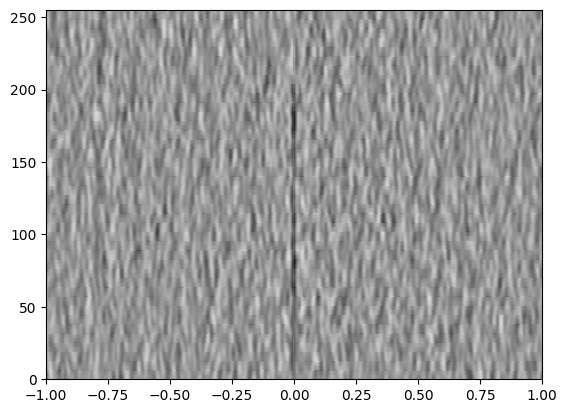

In [455]:
fig, ax = plt.subplots()

ax.pcolormesh(lag, np.arange(0,41,1)*6.38, np.mean(all_cc_pairs, axis=0),vmin=-5e-3, vmax = 5e-3, cmap='Greys', shading='gouraud')

# Stack the cross-correlations

In [ ]:
import yaml
cc_data_path = "/data/fast1/jm-scratch/output_eastwind_alldata/" 

config = ConfigParameters()
config.start_date = start
config.end_date = end
config.acorr_only = False # only perform auto-correlation or not
config.xcorr_only = True # only perform cross-correlation or not

config.inc_hours = 0
config.sampling_rate = 200  # (int) Sampling rate in Hz of desired processing (it can be different than the data sampling rate)
config.cc_len = 1  # (int) basic unit of data length for fft (sec)
config.step = 1.0  # (float) overlapping between each cc_len (sec)

config.ncomp = 1  # 1 or 3 component data (needed to decide whether do rotation)
config.stationxml = False  # station.XML file used to remove instrument response for SAC/miniseed data
config.rm_resp = RmResp.NO  # select 'no' to not remove response and use 'inv' if you use the stationXML,'spectrum',

############## NOISE PRE-PROCESSING ##################
config.freqmin, config.freqmax = 10., 40.0  # broad band filtering of the data before cross correlation
config.max_over_std  = 10*9  # threshold to remove window of bad signals: set it to 10*9 if prefer not to remove them

################### SPECTRAL NORMALIZATION ############
config.freq_norm = FreqNorm.RMA  # choose between "rma" for a soft whitening or "no" for no whitening. Pure whitening is not implemented correctly at this point.
config.smoothspect_N = 1  # moving window length to smooth spectrum amplitude (points)

#################### TEMPORAL NORMALIZATION ##########
config.time_norm = TimeNorm.ONE_BIT # 'no' for no normalization, or 'rma', 'one_bit' for normalization in time domain,
config.smooth_N = 100  # moving window length for time domain normalization if selected (points)

############ cross correlation ##############
config.cc_method = CCMethod.XCORR # 'xcorr' for pure cross correlation OR 'deconv' for deconvolution;

config.substack = False  # True = smaller stacks within the time chunk. False: it will stack over inc_hours
config.substack_windows = 1  # how long to stack over (for monitoring purpose): need to be multiples of cc_len

config.maxlag = 2  # lags of cross-correlation to save (sec)

config.networks = ["*"]

In [15]:
# open a new cc store in read-only mode since we will be doing parallel access for stacking
cc_store = NumpyCCStore(cc_data_path, mode="r")
stack_store = ASDFStackStore(stack_data_path)
config.stack_method = StackMethod.LINEAR

In [16]:
### Not working at the moment
stack_cross_correlations(cc_store, stack_store, config)

OSError: Abort! no available CCF data for stacking
0 total pairs found in the store. These filtered down to 0 pairs according to the config: stations=['*'], networks=['*']

In [458]:
# npts_segmt = int(2 * config.maxlag * config.sampling_rate) + 1

In [459]:

pairs = stack_store.get_station_pairs()
print(f"Found {len(pairs)} station pairs")
sta_stacks = stack_store.read_bulk(time_range, pairs) # no timestamp used in ASDFStackStore

# Save the configuration file
config.save_yaml(os.path.join(path, "config.yaml"))

Found 0 station pairs


Reading data: 0it [00:00, ?it/s]


In [460]:
# Collect data from sta_stacks
shots = []
offsets = []

for idx, i in enumerate(sta_stacks):
    src = int(i[0][0].name)
    rec = int(i[0][1].name)
    dist = abs(src - rec) * delta_space
    
    if src == cha_start:
        # Append shot and offset
        shots.append(i[1][1].data)  # waveform
        offsets.append(dist)

# Convert to numpy arrays
shots = np.array(shots)
offsets = np.array(offsets)
nx, ns = shots.shape

# Lag times in seconds
lag = np.linspace(-config.maxlag, config.maxlag, ns)

ValueError: not enough values to unpack (expected 2, got 1)

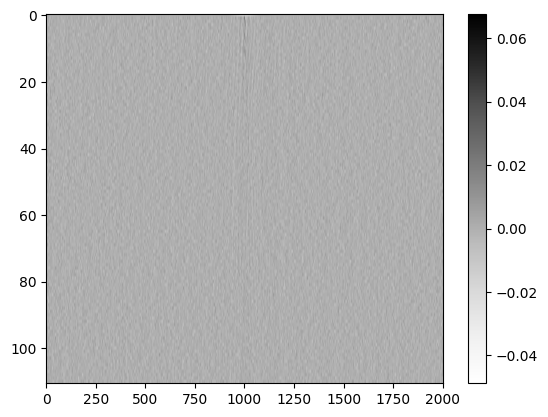

In [196]:
fig,ax = plt.subplots()
im = ax.imshow(shots, aspect='auto', cmap='Greys')
cbar =fig.colorbar(im, ax=ax)

In [31]:
shots.shape

(111, 2001)

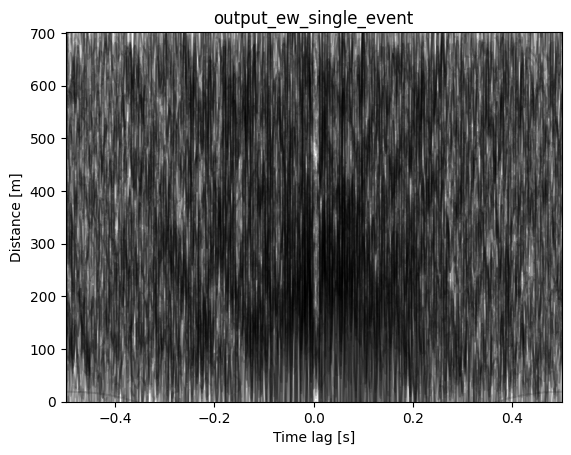

In [197]:
for ix in range(shots.shape[0]):
    plt.plot(lag, shots[ix]*10000 + offsets[ix], color='k', alpha=0.15)
plt.title(f'{path.split("/")[-1]}')
plt.xlabel('Time lag [s]')
plt.ylabel('Distance [m]')
plt.xlim(-config.maxlag+4.5,config.maxlag-4.5)
plt.ylim(0,offsets.max())
plt.show()

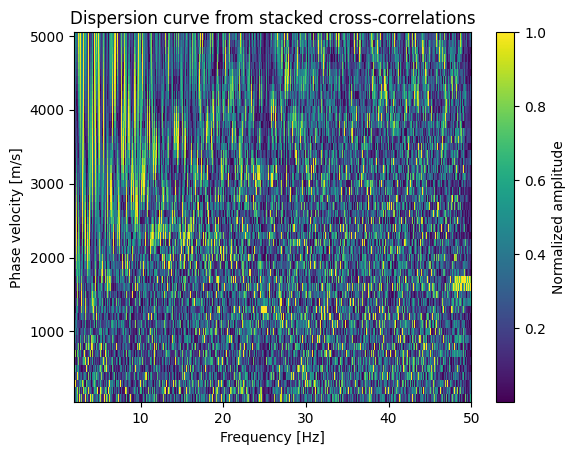

In [198]:

vs = np.linspace(100, 5000, 50)  # phase velocities to scan

# FFT along time axis
shotf = np.fft.rfft(shots, axis=1)
frq = np.fft.rfftfreq(ns, d=(lag[1]-lag[0]))

# Dispersion calculation
nv = len(vs)
disp = np.zeros((nv, len(frq)))

for iv, v in enumerate(vs):
    shifted = shotf.copy()
    for ix in range(nx):
        shifted[ix, :] *= np.exp(2j * np.pi * frq * offsets[ix] / v)
    disp[iv, :] = np.abs(np.mean(np.real(shifted), axis=0))

# Normalize (optional)
disp /= np.max(disp, axis=0, keepdims=True)

# Plot dispersion curve
plt.pcolormesh(frq, vs, disp, shading='auto')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Phase velocity [m/s]')
plt.xlim(config.freqmin, config.freqmax*0.5)
plt.colorbar(label='Normalized amplitude')
plt.title('Dispersion curve from stacked cross-correlations')
plt.show()